# Project 2: Understanding Missed Appointments (DNA) in NHS Primary Care

Missed appointments (Did Not Attend - DNA) reduce available clinical capacity and can contribute to inefficiencies within primary care services.

This project explores patterns in appointment attendance using NHS primary care appointment data, with a particular focus on understanding the factors associated with missed appointments.

## Objective

To investigate factors associated with missed appointments and identify patterns related to waiting times, appointment modes, healthcare professional types and seasonal variation.


## Questions

1. How common are missed appointments?
2. Do longer waiting times increase DNA rates?
3. Which appointment modes have the highest DNA rates?
4. Do DNA rates differ by healthcare professional type?
5. Are DNA rates seasonal?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
df = pd.read_csv("Regional_CSV_HertfordshireWEssex.csv")

In [3]:
df.shape

(20044, 13)

## Dataset Overview

The dataset contains aggregated NHS primary care appointment activity, including appointment outcomes, waiting times, appointment modes and healthcare professional types.

## Question 1: How Common Are Missed Appointments?

Understanding the scale of missed appointments provides context for the remainder of the analysis.

In [4]:
df["APPT_STATUS"].value_counts()

APPT_STATUS
Attended    7671
Unknown     7412
DNA         4961
Name: count, dtype: int64

In [5]:
status_pct = (
    df["APPT_STATUS"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

status_pct

APPT_STATUS
Attended    38.27
Unknown     36.98
DNA         24.75
Name: proportion, dtype: float64

### Finding

Missed appointments accounted for approximately 25% of recorded appointment outcomes in the dataset, indicating that non-attendance poses a significant operational challenge.

A substantial proportion of records were classified as "Unknown", highlighting potential limitations in data quality. However, DNA activity remained sufficiently prevalent to justify further investigation into the factors associated with missed appointments.

## Question 2: Do Longer Waiting Times Increase DNA Rates?

A common assumption is that patients are more likely to miss appointments when waiting times are longer.

This section evaluates whether DNA rates increase as the gap between booking and appointment date grows.

In [6]:
dna_wait = (
    df[df["APPT_STATUS"] == "DNA"]
    .groupby("TIME_BETWEEN_BOOK_AND_APPT")["COUNT_OF_APPOINTMENTS"]
    .sum()
    .sort_values(ascending=False)
)

dna_wait

TIME_BETWEEN_BOOK_AND_APPT
2 to 7 Days               175155
8  to 14 Days             163874
Same Day                  123147
15  to 21 Days            112674
More than 28 Days          84871
22  to 28 Days             77338
1 Day                      50275
Unknown / Data Quality       193
Name: COUNT_OF_APPOINTMENTS, dtype: int64

In [7]:
wait_totals = (
    df.groupby("TIME_BETWEEN_BOOK_AND_APPT")["COUNT_OF_APPOINTMENTS"]
    .sum()
)

wait_totals

TIME_BETWEEN_BOOK_AND_APPT
1 Day                     1492472
15  to 21 Days            1681130
2 to 7 Days               3652592
22  to 28 Days            1123198
8  to 14 Days             2739187
More than 28 Days         1130229
Same Day                  9738254
Unknown / Data Quality      11776
Name: COUNT_OF_APPOINTMENTS, dtype: int64

In [8]:
dna_counts = (
    df[df["APPT_STATUS"] == "DNA"]
    .groupby("TIME_BETWEEN_BOOK_AND_APPT")["COUNT_OF_APPOINTMENTS"]
    .sum()
)

wait_totals = (
    df.groupby("TIME_BETWEEN_BOOK_AND_APPT")["COUNT_OF_APPOINTMENTS"]
    .sum()
)

dna_rate = (
    (dna_counts / wait_totals) * 100
).round(2)

dna_rate.sort_values(ascending=False)

TIME_BETWEEN_BOOK_AND_APPT
More than 28 Days         7.51
22  to 28 Days            6.89
15  to 21 Days            6.70
8  to 14 Days             5.98
2 to 7 Days               4.80
1 Day                     3.37
Unknown / Data Quality    1.64
Same Day                  1.26
Name: COUNT_OF_APPOINTMENTS, dtype: float64

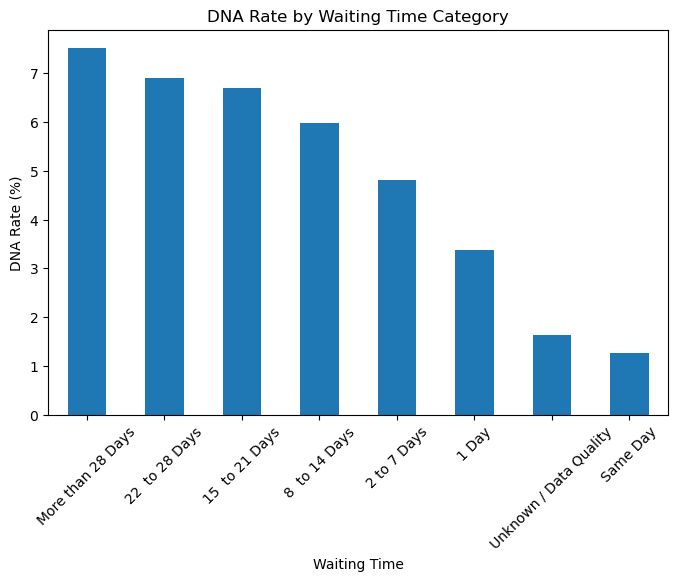

In [9]:
dna_rate = dna_rate.sort_values(ascending=False)

plt.figure(figsize=(8,5))
dna_rate.plot(kind="bar")

plt.title("DNA Rate by Waiting Time Category")
plt.xlabel("Waiting Time")
plt.ylabel("DNA Rate (%)")
plt.xticks(rotation=45)

plt.show()

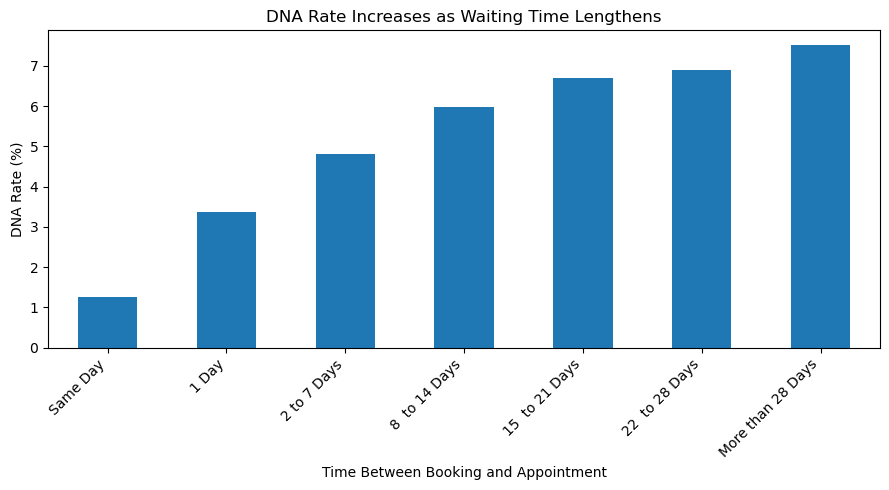

In [10]:
wait_order = [
    "Same Day",
    "1 Day",
    "2 to 7 Days",
    "8  to 14 Days",
    "15  to 21 Days",
    "22  to 28 Days",
    "More than 28 Days"
]

dna_rate_ordered = dna_rate.loc[wait_order]

plt.figure(figsize=(9, 5))
dna_rate_ordered.plot(kind="bar")

plt.title("DNA Rate Increases as Waiting Time Lengthens")
plt.xlabel("Time Between Booking and Appointment")
plt.ylabel("DNA Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Finding

DNA rates increased consistently as waiting times lengthened. Same-day appointments recorded the lowest DNA rate, while appointments booked more than 28 days in advance recorded the highest. This pattern suggests that longer delays between booking and appointment dates may reduce patient engagement and increase the likelihood of missed appointments.

The relationship between waiting time and DNA rates was the strongest pattern identified within the analysis, highlighting appointment delays as a potential operational driver of non-attendance.

## Question 3: Which Appointment Modes Have the Highest DNA Rates?

Different appointment delivery methods may influence attendance behaviour.

This section compares DNA rates across appointment modes.

In [11]:
df["APPT_MODE"].value_counts()

APPT_MODE
Face-to-Face    4517
Unknown         4440
Telephone       4223
Home Visit      3627
Video/Online    3237
Name: count, dtype: int64

In [12]:
mode_totals = (
    df.groupby("APPT_MODE")["COUNT_OF_APPOINTMENTS"]
    .sum()
    .sort_values(ascending=False)
)

mode_totals

APPT_MODE
Face-to-Face    14464244
Telephone        5116714
Video/Online     1146854
Unknown           660028
Home Visit        180998
Name: COUNT_OF_APPOINTMENTS, dtype: int64

In [13]:
# DNA appointments by mode
dna_mode = (
    df[df["APPT_STATUS"] == "DNA"]
    .groupby("APPT_MODE")["COUNT_OF_APPOINTMENTS"]
    .sum()
)

# Total appointments by mode
mode_totals = (
    df.groupby("APPT_MODE")["COUNT_OF_APPOINTMENTS"]
    .sum()
)

# DNA rate by mode
dna_mode_rate = (
    dna_mode / mode_totals * 100
).round(2).sort_values(ascending=False)

dna_mode_rate

APPT_MODE
Face-to-Face    4.70
Telephone       1.73
Home Visit      1.44
Unknown         1.21
Video/Online    0.67
Name: COUNT_OF_APPOINTMENTS, dtype: float64

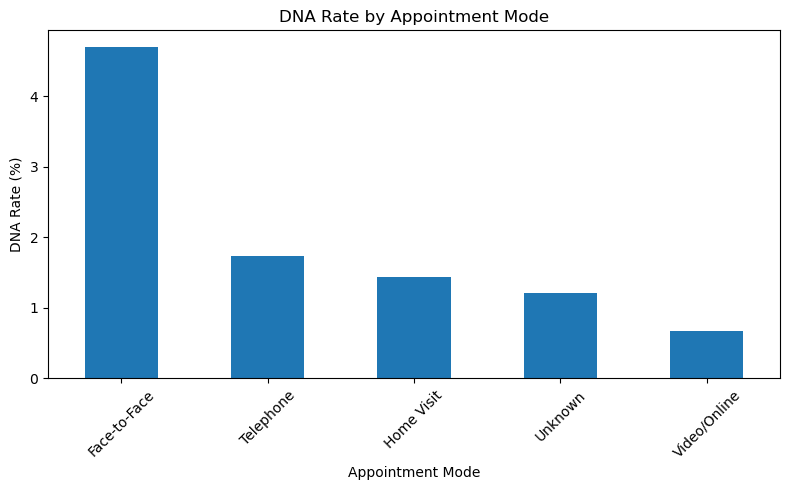

In [14]:
plt.figure(figsize=(8,5))
dna_mode_rate.plot(kind="bar", rot=0)

plt.title("DNA Rate by Appointment Mode")
plt.xlabel("Appointment Mode")
plt.ylabel("DNA Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Finding

Face-to-face appointments recorded the highest DNA rate among all appointment modes analysed. In contrast, telephone and video/online appointments exhibited considerably lower non-attendance rates.

This finding suggests that appointment delivery method may influence attendance behaviour, with remote consultation formats potentially reducing barriers to access and improving attendance rates.

## Question 4: Do DNA Rates Differ by Healthcare Professional Type?

This analysis compares attendance patterns across different staff groups.

In [15]:
df["HCP_TYPE"].value_counts()

HCP_TYPE
Other Practice staff    8583
GP                      8232
Unknown                 3229
Name: count, dtype: int64

In [16]:
hcp_totals = (
    df.groupby("HCP_TYPE")["COUNT_OF_APPOINTMENTS"]
    .sum()
    .sort_values(ascending=False)
)

hcp_totals

HCP_TYPE
GP                      11151727
Other Practice staff     9923554
Unknown                   493557
Name: COUNT_OF_APPOINTMENTS, dtype: int64

In [17]:
#dna by hcp
dna_hcp = (
    df[df["APPT_STATUS"] == "DNA"]
    .groupby("HCP_TYPE")["COUNT_OF_APPOINTMENTS"]
    .sum()
)

#dna total by hcp
hcp_totals = (
    df.groupby("HCP_TYPE")["COUNT_OF_APPOINTMENTS"]
    .sum()
)

#dna rate by hcp
dna_hcp_rate = (
    dna_hcp / hcp_totals * 100
).round(2).sort_values(ascending=False)

dna_hcp_rate

HCP_TYPE
Other Practice staff    5.11
GP                      2.46
Unknown                 1.15
Name: COUNT_OF_APPOINTMENTS, dtype: float64

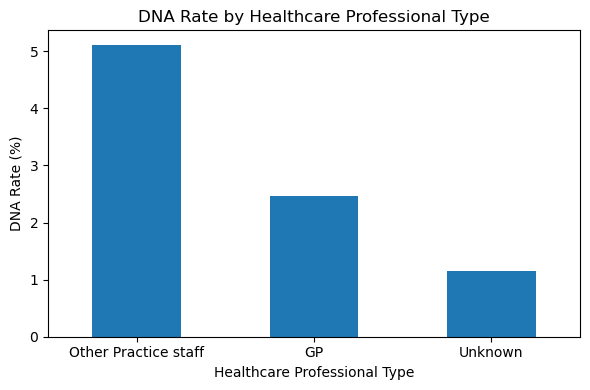

In [18]:
plt.figure(figsize=(6,4))
dna_hcp_rate.plot(kind="bar", rot=0)

plt.title("DNA Rate by Healthcare Professional Type")
plt.xlabel("Healthcare Professional Type")
plt.ylabel("DNA Rate (%)")

plt.tight_layout()
plt.show()

### Finding

DNA rates differed across healthcare professional types, with appointments involving Other Practice Staff recording higher DNA rates than those involving GPs.

While the dataset does not provide a more detailed breakdown of staff categories, the results suggest that attendance behaviour may vary by service type, reflecting differences in appointment purpose, patient perceptions, or service utilisation patterns

## Question 5: Are DNA Rates Seasonal?

This section examines whether DNA rates vary throughout the year.

In [20]:
#dna appointments by month
dna_month = (
    df[df["APPT_STATUS"] == "DNA"]
    .groupby("APPOINTMENT_MONTH")["COUNT_OF_APPOINTMENTS"]
    .sum()
)

#total appointments by month
month_totals = (
    df.groupby("APPOINTMENT_MONTH")["COUNT_OF_APPOINTMENTS"]
    .sum()
)

#dna rate by month
dna_month_rate = (
    dna_month / month_totals * 100
).round(2)

dna_month_rate

APPOINTMENT_MONTH
APR2024    3.88
APR2025    3.32
AUG2024    3.46
AUG2025    3.29
DEC2023    3.89
DEC2024    3.47
DEC2025    3.53
FEB2024    3.47
FEB2025    3.13
FEB2026    3.34
JAN2024    3.49
JAN2025    3.17
JAN2026    3.24
JUL2024    3.77
JUL2025    3.32
JUN2024    3.49
JUN2025    3.23
MAR2024    3.52
MAR2025    3.16
MAR2026    3.36
MAY2024    3.51
MAY2025    3.34
NOV2023    4.04
NOV2024    3.76
NOV2025    3.43
OCT2023    5.99
OCT2024    4.70
OCT2025    4.46
SEP2024    3.57
SEP2025    3.43
Name: COUNT_OF_APPOINTMENTS, dtype: float64

In [21]:
dna_month_rate_df = dna_month_rate.reset_index()

dna_month_rate_df["APPOINTMENT_MONTH"] = pd.to_datetime(
    dna_month_rate_df["APPOINTMENT_MONTH"],
    format="%b%Y"
)

dna_month_rate_df = dna_month_rate_df.sort_values(
    "APPOINTMENT_MONTH"
)

dna_month_rate_df

,APPOINTMENT_MONTH,COUNT_OF_APPOINTMENTS
25,2023-10-01,5.99
22,2023-11-01,4.04
4,2023-12-01,3.89
10,2024-01-01,3.49
7,2024-02-01,3.47
17,2024-03-01,3.52
0,2024-04-01,3.88
20,2024-05-01,3.51
15,2024-06-01,3.49
13,2024-07-01,3.77


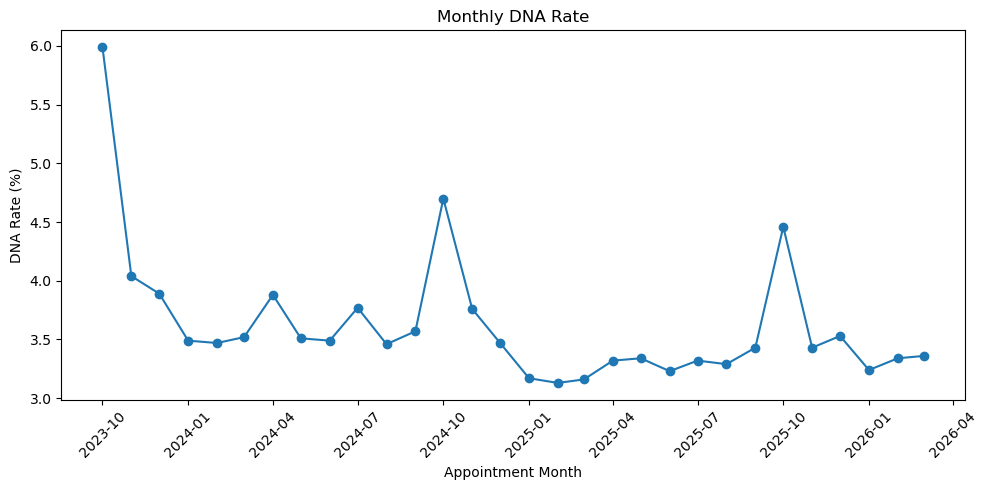

In [22]:
plt.figure(figsize=(10,5))

plt.plot(
    dna_month_rate_df["APPOINTMENT_MONTH"],
    dna_month_rate_df["COUNT_OF_APPOINTMENTS"],
    marker="o"
)

plt.title("Monthly DNA Rate")
plt.xlabel("Appointment Month")
plt.ylabel("DNA Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Finding

Monthly DNA rates remained relatively stable throughout the study period, with most months recording rates between 3% and 4%.

However, October consistently exhibited elevated DNA rates across multiple years, indicating a potential seasonal effect. Despite these recurring peaks, variation by month was modest compared with the substantially stronger relationship observed between waiting times and DNA rates.

# Key Findings

- Missed appointments accounted for a meaningful proportion of appointment outcomes within the dataset.
- DNA rates increased steadily as appointment waiting times lengthened.
- Face-to-face appointments exhibited higher DNA rates than telephone and video/online appointments.
- Appointments involving Other Practice Staff recorded higher DNA rates than GP appointments.
- Monthly DNA rates were generally stable, although October consistently recorded elevated DNA rates.

# Conclusion

This analysis explored factors associated with missed appointments within NHS primary care services.

The strongest relationship identified was between appointment waiting times and DNA rates, with patients becoming progressively more likely to miss appointments as the delay between booking and appointment increased. Appointment mode and healthcare professional type also appeared to influence attendance behaviour, while seasonal variation was relatively modest.

These findings suggest that reducing waiting times and understanding differences in attendance behaviour across service types may help practices improve appointment utilisation and maximise available clinical capacity.

In [23]:
df.columns.tolist()

['SUB_ICB_LOCATION_CODE',
 'SUB_ICB_LOCATION_ONS_CODE',
 'SUB_ICB_LOCATION_NAME',
 'ICB_ONS_CODE',
 'ICB_NAME',
 'REGION_ONS_CODE',
 'REGION_NAME',
 'APPOINTMENT_MONTH',
 'APPT_STATUS',
 'HCP_TYPE',
 'APPT_MODE',
 'TIME_BETWEEN_BOOK_AND_APPT',
 'COUNT_OF_APPOINTMENTS']